# Project 2: Predicting Water Point Functionality and Identifying Contributing Factors

**Luxor Bourommavong | DTSC 2301 | Project 2**

## 1. Problem Definition

**Research Question:** What factors contribute the most to the functionality of a public water point, and can a water point's condition be predicted to make infrastructure maintenance more proactive?

**Prediction problem.** Given basic information about a water point (where it is, what kind of pump it uses, who manages it, how old it is, how much water it yields, and so on), can we predict its current operating condition?

**Target variable.** `status_group`, with three possible values: `functional`, `functional needs repair`, and `non functional`.

This will be a **classification** problem. The "needs repair" class is the one that matters most for proactive maintenance, but it is also the rarest, which makes it the hardest to predict.

**Who benefits.** Government water agencies and NGOs have limited repair budgets and cannot inspect every water point. A model that ranks water points by likelihood of failure helps them send crews to the right places first. Communities benefit when a failing pump is fixed before it becomes non-functional.

**Why it matters.** Reliable access to safe drinking water is a basic public health need (and a UN Sustainable Development Goal). A water point that sits broken means people walk farther, or fall back on unsafe sources. Finding out *why* points fail, not just *which* ones, also helps decide where to build new ones and which designs and management models last.

## 2. Background and Context

**A widespread problem.** Water points that remain broken are a major obstacle to safe and reliable rural water supplies. Foster et al. (2020) reviewed handpump functionality data from sub-Saharan Africa and the Asia-Pacific and found that roughly one in four handpumps is non-functional at any given time, which represents billions of dollars of wasted investment. Chellaraj et al. (2019) studied the same problem in Tanzania, where this data comes from, and examined the factors that contribute to water point failure.

**What earlier research says about failure.** Studies point to a mix of technical, managerial, and financial factors. Foster (2013) analyzed about 25,000 community-managed handpumps in Liberia, Sierra Leone, and Uganda and found that older systems, systems farther from the district capital, and systems with no user-fee collection were more likely to become non-functional. Jiménez and Pérez-Foguet (2011), using a water point mapping study of 15 rural districts in Tanzania, found that about 30% of water points stop working within five years, that handpumps were the least durable technology, and that points managed by village committees failed more often than those run by private operators. Several of these factors are recorded in the data used here: `age` (transformed from `construction_year`), `payment_type`, `management`, `extraction_type`, and `waterpoint_type`.

**Project purpose** Most of this research explains the reasons why water points might fail. This project seeks to see if, using information that a survey team can record once, can we *predict* which water points are broken or need repair, so that limited maintenance resources go to the right places first? 

## 3. Data Description

The data comes from the DrivenData competition [*Pump it Up: Data Mining the Water Table*](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/). It was collected by [Taarifa](http://taarifa.org/) (a platform for crowdsourced reporting of public service problems) in partnership with the Tanzanian Ministry of Water. The files used here are the competition's training set values (`IndiVaris.csv`), the individual features of each waterpoint, and training set labels (`DepVaris.csv`), the status of each waterpoint.

**Unit of analysis.** Each row is a single **water point** (one pump, tap, spring, or well) in Tanzania. The two files are linked by the unique `id` column.

**Size.** 59,400 water points and 40 candidate features (plus `id`).

**Target.** `status_group`: functional, non functional, functional needs repair.

**Features available**:
- **Location:** `latitude`, `longitude`, `gps_height`, `basin`, `region`, `region_code`, `district_code`, `lga`, `ward`, `subvillage`
- **Water point technology:** `extraction_type` (plus `_group` and `_class` versions), `waterpoint_type` (plus `_group`), `source` (plus `_type` and `_class`)
- **Management and funding:** `funder`, `installer`, `management`, `management_group`, `scheme_management`, `scheme_name`, `permit`, `public_meeting`
- **Payment:** `payment`, `payment_type`
- **Water characteristics:** `water_quality`, `quality_group`, `quantity`, `quantity_group`, `amount_tsh` (total static head, a measure of available water pressure/volume)
- **Other:** `construction_year`, `population` (people near the point), `date_recorded`, `wpt_name`, `num_private`, `recorded_by`

**Assumptions and limitations.**
- Data was gathered by surveyors and crowdsourced reports, so accuracy can vary by region, and some fields were filled in inconsistently (e.g., `funder`/`installer` spelled many different ways).
- Only Tanzania is examined, so the model cannot be assumed to explain other countries.

### 3.1 Setup

In [26]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### 3.2 Loading and Merging the Data

The features and the labels live in separate files, so they are joined on `id`. A left join keeps every water point in the feature file; the check below confirms that every one found a label.

In [27]:
target = pd.read_csv('DepVaris.csv')
features = pd.read_csv('IndiVaris.csv')
target.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


In [28]:
features.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [29]:
water_data: pd.DataFrame = features.merge(
    right = target,
    left_on = ['id'],
    right_on = ['id'],
    how = "left",
)

display(water_data)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59395,60739,10.0,2013-05-03,Germany Republi,1210,CES,37.169807,-3.253847,Area Three Namba 27,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
59396,27263,4700.0,2011-05-07,Cefa-njombe,1212,Cefa,35.249991,-9.070629,Kwa Yahona Kuvala,0,...,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe,functional
59397,37057,0.0,2011-04-11,NaN,0,NaN,34.017087,-8.750434,Mashine,0,...,fluoride,fluoride,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump,functional
59398,31282,0.0,2011-03-08,Malec,0,Musa,35.861315,-6.378573,Mshoro,0,...,soft,good,insufficient,insufficient,shallow well,shallow well,groundwater,hand pump,hand pump,functional


## 4. Data Understanding and Exploration

### 4.1 Target distribution (`status_group`)

Class Distribution of target variable, 'status_group'

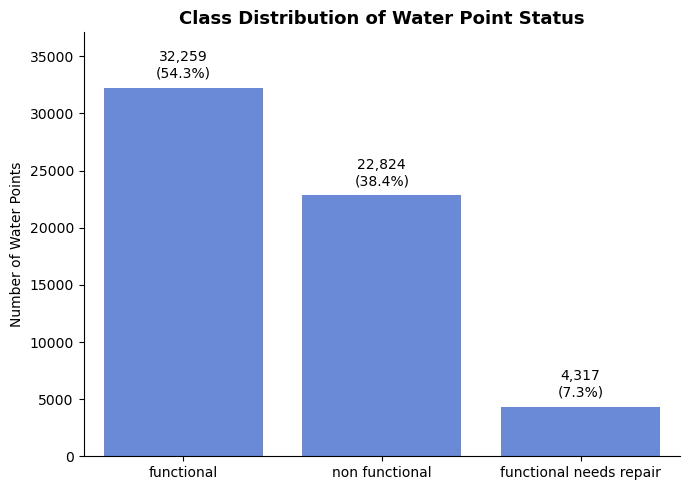

In [30]:
class_counts = water_data['status_group'].value_counts()
class_pct = water_data['status_group'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#5783EB", ax=ax)

for i, count in enumerate(class_counts.values):
    ax.text(
        i, count + (class_counts.max() * 0.02),
        f"{count:,}\n({class_pct.iloc[i]:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Class Distribution of Water Point Status", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Water Points")
ax.set_ylim(0, class_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

The classes are evidently imbalanced: "functional needs repair" is only 7.3% of the data. A model that ignores that class could still seem fairly accurate, so accuracy alone would be a poor metric here. I will use macro-F1 and per-class recall, and stratify the train/test split so the minority status is not underrepresented.

### 4.2 Missing values

Explicit missing values (blank cells) first.

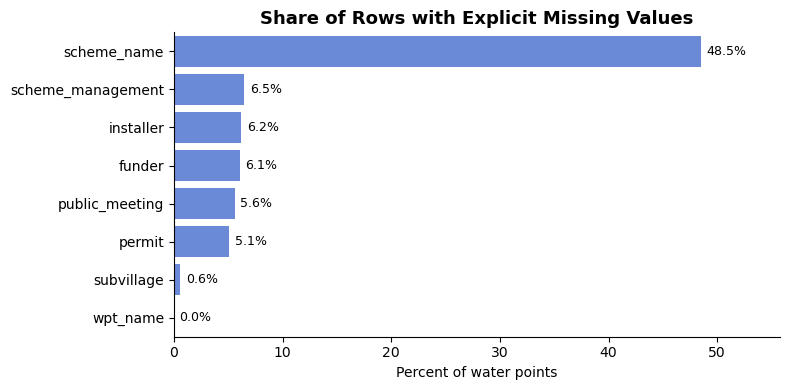

In [31]:
missing = (water_data.isna().sum()
           .loc[lambda s: s > 0]
           .sort_values(ascending=False)
           .to_frame("n_missing"))
missing["pct_missing"] = (missing["n_missing"] / len(water_data) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing["pct_missing"], y=missing.index, color="#5783EB", ax=ax)
for i, v in enumerate(missing["pct_missing"]):
    ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
ax.set_title("Share of Rows with Explicit Missing Values", fontsize=13, weight="bold")
ax.set_xlabel("Percent of water points")
ax.set_ylabel("")
ax.set_xlim(0, missing["pct_missing"].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

`scheme_name` is missing for nearly half of rows, so it would be mostly unhelpful as a feature. The others are missing for 5 to 6% of rows, small enough to fill in with an "unknown" category instead of having to drop rows.

### 4.3 Zero Data Points

Several numeric columns contain `0` where it would not make sense (a water point built in year 0, or being at longitude 0). These are presumably placeholders for unrecorded data.

In [32]:
zero_cols = ["amount_tsh", "gps_height", "longitude", "construction_year", "population", "num_private"]
zeros = pd.DataFrame({
    "n_zero": [(water_data[c] == 0).sum() for c in zero_cols],
    "pct_zero": [round((water_data[c] == 0).mean() * 100, 1) for c in zero_cols],
}, index=zero_cols)
display(zeros)

# Status mix when the value is a hidden zero vs. recorded
for c in ["construction_year", "amount_tsh"]:
    print(f"\n{c}:")
    display((water_data.groupby(water_data[c] == 0)["status_group"]
             .value_counts(normalize=True).unstack().round(2)
             .rename_axis(f"{c} == 0")))

,n_zero,pct_zero
amount_tsh,41639,70.1
gps_height,20438,34.4
longitude,1812,3.1
construction_year,20709,34.9
population,21381,36.0
num_private,58643,98.7



construction_year:


status_group,functional,functional needs repair,non functional
construction_year == 0,,,
False,0.56,0.07,0.37
True,0.51,0.09,0.40



amount_tsh:


status_group,functional,functional needs repair,non functional
amount_tsh == 0,,,
False,0.71,0.07,0.22
True,0.47,0.07,0.45


About a third of `construction_year` and `population` values, and 70% of `amount_tsh`, are zeros. `num_private` is zero for 98.7% of rows, so it carries almost no information.

For `amount_tsh`, zero water-head is strongly tied to non-functional status (45% non-functional vs. 22% otherwise), so the zero may be real (a dry water point yields nothing). It can be kept as a feature.

### 4.4 Categorical features vs. the target

The charts below show, for each category, the proportion of water points in each status. Categories are sorted by the non-functional rate; the number of water points in each is shown in the label so tiny categories are not over-read.

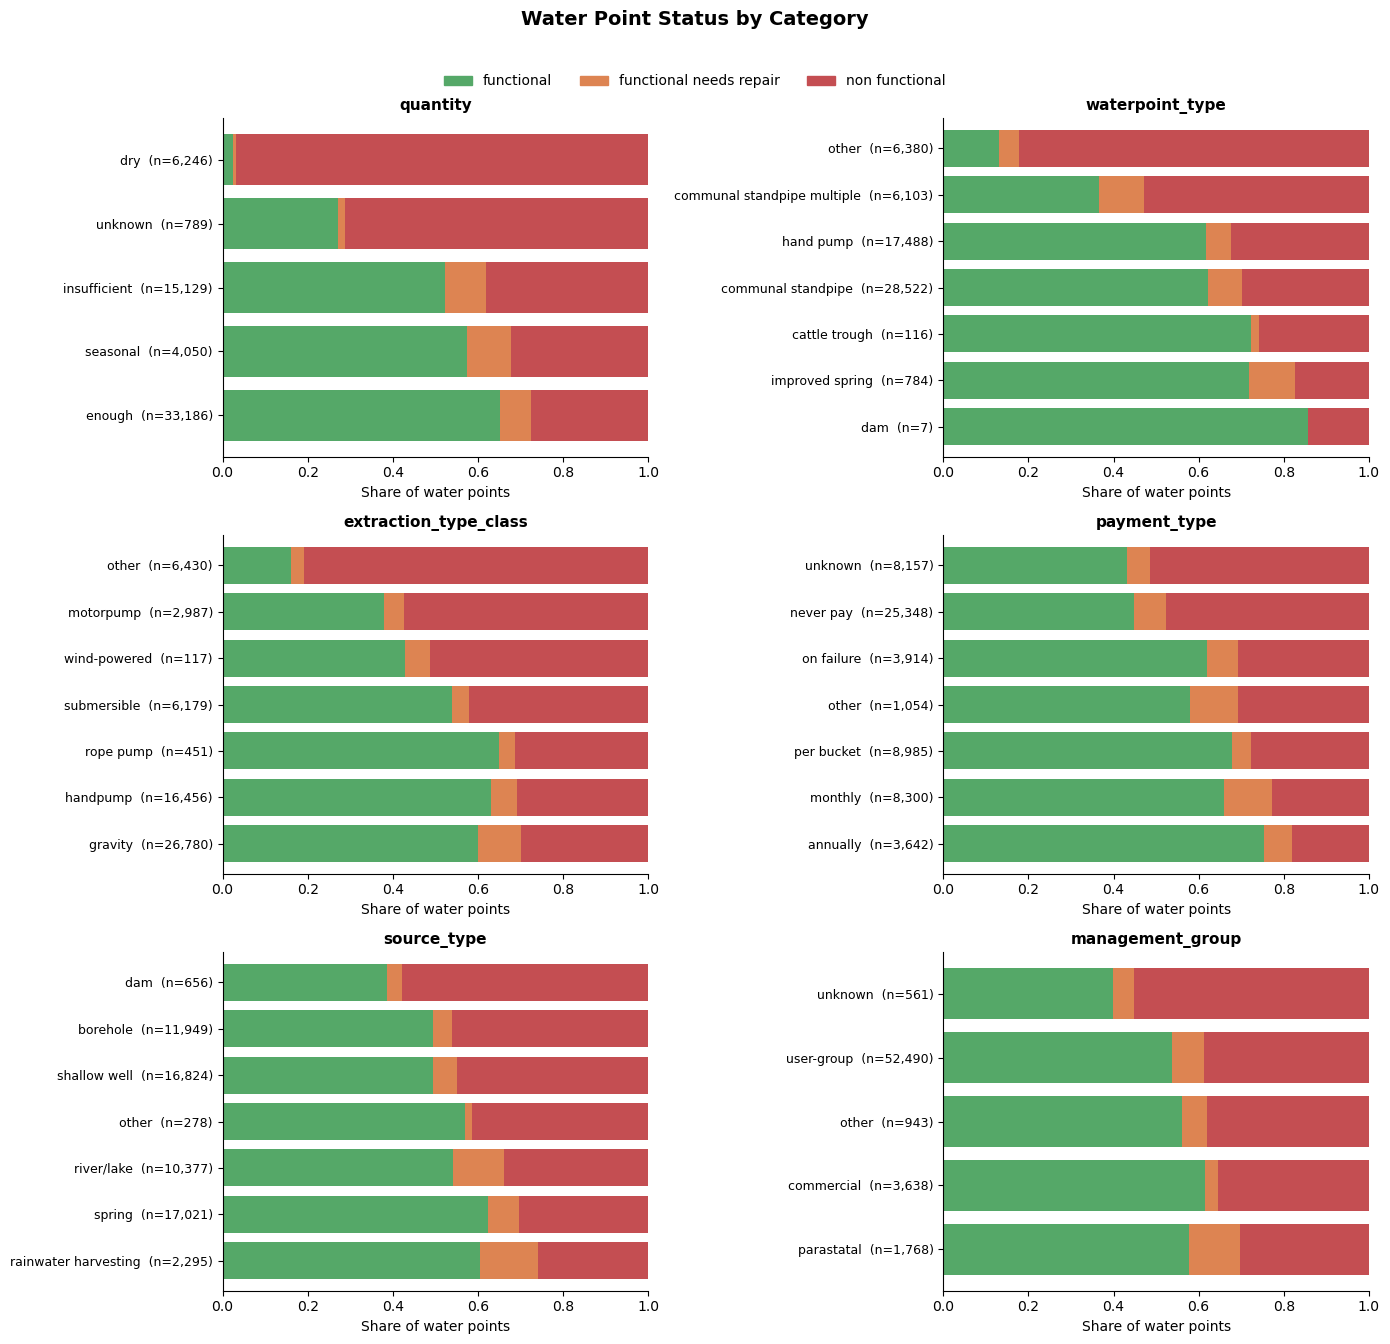

In [33]:
status_order = ["functional", "functional needs repair", "non functional"]
status_colors = {"functional": "#55A868", "functional needs repair": "#DD8452", "non functional": "#C44E52"}

def plot_status_by(col, ax, top=None):
    ct = pd.crosstab(water_data[col], water_data["status_group"])[status_order]
    if top:
        ct = ct.loc[ct.sum(axis=1).nlargest(top).index]
    pct = ct.div(ct.sum(axis=1), axis=0).sort_values("non functional")
    pct.plot(kind="barh", stacked=True, ax=ax, color=[status_colors[s] for s in status_order], legend=False, width=0.8)
    ax.set_yticklabels([f"{i}  (n={ct.loc[i].sum():,})" for i in pct.index], fontsize=9)
    ax.set_title(col, fontsize=11, weight="bold")
    ax.set_xlabel("Share of water points")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)
    sns.despine(ax=ax)

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for col, ax in zip(["quantity", "waterpoint_type", "extraction_type_class", "payment_type", "source_type", "management_group"], axes.flat):
    plot_status_by(col, ax)
handles = [plt.Rectangle((0, 0), 1, 1, color=status_colors[s]) for s in status_order]
fig.legend(handles, status_order, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.99))
fig.suptitle("Water Point Status by Category", fontsize=14, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

**Findings.**
- **`quantity`** is the single strongest signal: 97% of points that are `dry` are non-functional.
- **`waterpoint_type` and `extraction_type_class`**: the vague "other" category has an 81 to 82% non-functional rate, far above the roughly 30% for hand pumps and standpipes. "Other" could be a catch-all that includes abandoned or unusual installations.
- **`payment_type`**: points where users `never pay` are 48% non-functional, versus 18% for annual payment. Communities that collect fees can afford upkeep.
- **`management_group`** and **`source_type`** show weaker differences.

### 4.5 Geography: region and map

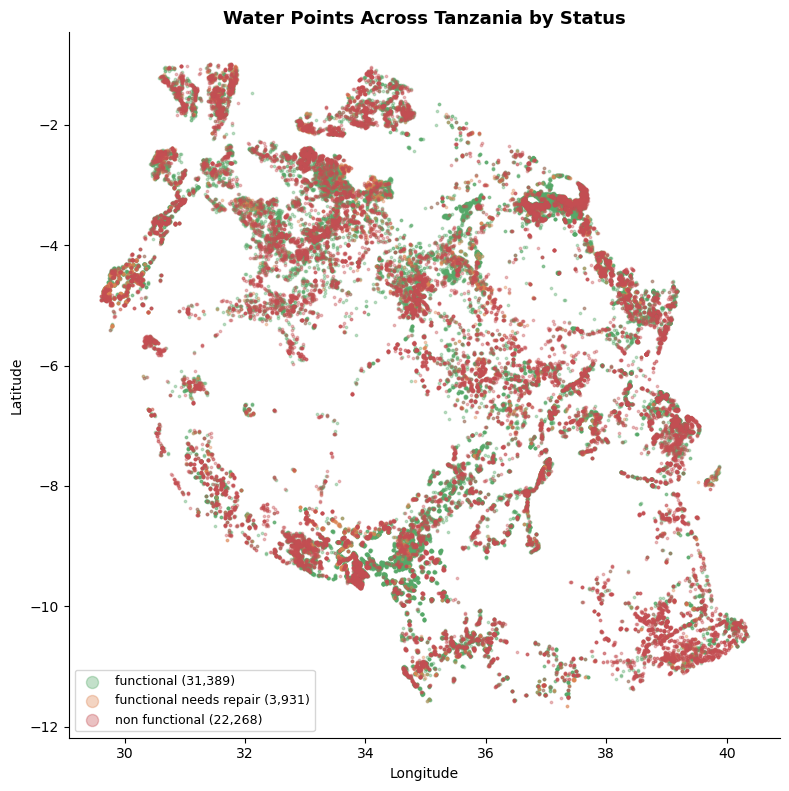

In [34]:
geo = water_data[(water_data["longitude"] != 0)]
fig, ax = plt.subplots(figsize=(8, 8))
for s in status_order:
    sub = geo[geo["status_group"] == s]
    ax.scatter(sub["longitude"], sub["latitude"], s=3, alpha=0.35, color=status_colors[s], label=f"{s} ({len(sub):,})")
ax.set_title("Water Points Across Tanzania by Status", fontsize=13, weight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=5, loc="lower left", fontsize=9)
ax.set_aspect("equal")
sns.despine()
plt.tight_layout()
plt.show()

**Findings.** Condition varies a lot by place: the non-functional rate is about 19% in Iringa but 62 to 64% in Mtwara and Lindi (the southeast). The map shows clusters of non-functional points rather than a random scatter, so location (latitude/longitude, region, basin) should be a useful predictor. This also means a random train/test split may be somewhat optimistic, because neighboring water points share conditions.

### 4.6 Age of the water point

Age is not in the data directly, but it can be derived: the year recorded minus the construction year (using only rows where the construction year is known).

Rows with age < 0 (built after it was recorded): 9


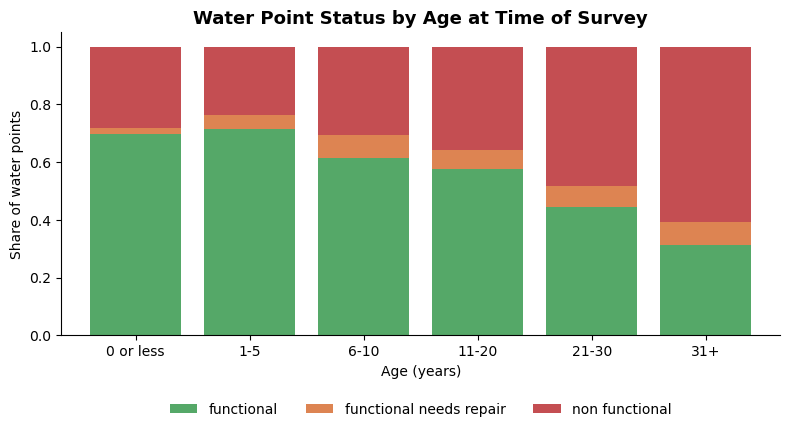

In [35]:
age_df = water_data[water_data["construction_year"] > 0].copy()
age_df["age"] = pd.to_datetime(age_df["date_recorded"]).dt.year - age_df["construction_year"]
print(f"Rows with age < 0 (built after it was recorded): {(age_df['age'] < 0).sum()}")

age_df["age_bin"] = pd.cut(age_df["age"], bins=[-10, 0, 5, 10, 20, 30, 60],
                           labels=["0 or less", "1-5", "6-10", "11-20", "21-30", "31+"])
age_ct = pd.crosstab(age_df["age_bin"], age_df["status_group"], normalize="index")[status_order]

fig, ax = plt.subplots(figsize=(8, 4.5))
age_ct.plot(kind="bar", stacked=True, ax=ax, color=[status_colors[s] for s in status_order], width=0.8)
ax.set_title("Water Point Status by Age at Time of Survey", fontsize=13, weight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Share of water points")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
sns.despine()
plt.tight_layout()
plt.show()

**Finding.** Older points fail more often: the non-functional share climbs from about 24 to 28% for points built within the last 5 years to 61% for those older than 30. A handful of rows have negative ages (recorded before construction year), which signals data-entry errors. Because age shows a clear, interpretable trend, I will engineer an `age` feature rather than using the raw construction year.

### 4.7 Redundant columns

In [36]:
print("\nNear-duplicate column families (number of unique values):")
families = {
    "quantity": ["quantity", "quantity_group"],
    "extraction": ["extraction_type", "extraction_type_group", "extraction_type_class"],
    "payment": ["payment", "payment_type"],
    "water quality": ["water_quality", "quality_group"],
    "source": ["source", "source_type", "source_class"],
    "waterpoint type": ["waterpoint_type", "waterpoint_type_group"],
    "management": ["management", "management_group"],
}
for name, cols in families.items():
    print(f"  {name:16s}", {c: water_data[c].nunique() for c in cols})


Near-duplicate column families (number of unique values):
  quantity         {'quantity': 5, 'quantity_group': 5}
  extraction       {'extraction_type': 18, 'extraction_type_group': 13, 'extraction_type_class': 7}
  payment          {'payment': 7, 'payment_type': 7}
  water quality    {'water_quality': 8, 'quality_group': 6}
  source           {'source': 10, 'source_type': 7, 'source_class': 3}
  waterpoint type  {'waterpoint_type': 7, 'waterpoint_type_group': 6}
  management       {'management': 12, 'management_group': 5}


**Findings.**
- `funder` (1,896), `installer` (2,145), `ward` (2,092), `scheme_name` (2,695), `subvillage` (19,287), and `wpt_name` (37,399) have far too many levels to one-hot encode usefully. `wpt_name` and `subvillage` are close to unique identifiers, so they could induce overfitting rather than learning.
- `recorded_by` has a single value and carries no information.
- Several column families repeat the same information at different levels of detail (e.g., `payment` and `payment_type` appear identical; `quantity` and `quantity_group` too). Keeping all of them adds redundancy.

### 4.8 Summary of exploration and decisions carried forward

| Finding | Modeling Decision |
|---|---|
| Imbalanced target (7% "needs repair") | Stratified split; judge models with macro-F1 and per-class recall, not accuracy |
| Zeros in `construction_year`, `longitude`, `gps_height`, `population` are hidden missing values | Convert to missing, then fill with the median (learned from training data) |
| Skewed `amount_tsh` and `population` | Keep as is (only rescaled). Tree models are not affected by skew; this may slightly hurt the linear model |
| Age strongly related to status | Create `age` from `date_recorded` and `construction_year` |
| Redundant column families | Keep one per family |
| High-cardinality `funder`, `installer` (about 2,000 levels each) | Drop (too many categories to encode simply) |
| `scheme_name`, `wpt_name`, `subvillage`, `recorded_by`, `num_private`, `id` | Drop (too sparse, identifier-like, or constant) |
| Location matters and points cluster | Keep coordinates, region, and basin|

## 5. Data Preparation and Feature Selection

### 5.1 Cleaning

| Issue | Decision | Why |
|---|---|---|
| Zeros in `gps_height`, `longitude`, `population`, `construction_year` | Replace with missing | A value of 0 is impossible or a placeholder|
| Latitude on rows where longitude is 0 | Replace with missing | Missing coordinates likely to be a data input mistake|
| `amount_tsh` zeros | Keep, and add a `amount_tsh_zero` flag | Zero is tied to non-functional status (Section 4.3), so it may be real information |
| `construction_year` | Convert to `age` = year recorded minus construction year; negative ages become missing | Age has a clear trend with status (Section 4.7), and negative ages are entry errors |
| `public_meeting`, `permit` | Convert True/False to `yes`/`no` text, leaving blanks missing | Lets them be handled like the other categorical columns |
| 36 duplicate rows (ignoring `id`) | Keep | They have different ids, so they are probably different water points that share all recorded attributes. 36 of 59,400 rows is too few to matter |

In [37]:
model_df = water_data.copy()

# Latitude is only ~0 when the GPS reading failed (longitude == 0), so blank it first
model_df.loc[model_df["longitude"] == 0, "latitude"] = np.nan

# Zeros that really mean "not recorded"
for col in ["gps_height", "longitude", "population", "construction_year"]:
    model_df[col] = model_df[col].replace(0, np.nan)

# Keep the amount_tsh zeros but flag them
model_df["amount_tsh_zero"] = (model_df["amount_tsh"] == 0).astype(int)

# Age of the water point at the time of the survey (negative ages are data-entry errors)
model_df["age"] = pd.to_datetime(model_df["date_recorded"]).dt.year - model_df["construction_year"]
model_df.loc[model_df["age"] < 0, "age"] = np.nan

# True/False -> text so they behave like other categorical columns
for col in ["public_meeting", "permit"]:
    model_df[col] = model_df[col].map({True: "yes", False: "no"})

print("\nMissing values in the derived/cleaned numeric columns:")
print(model_df[["gps_height", "longitude", "latitude", "population", "age"]].isna().mean().mul(100).round(1).astype(str) + "%")


Missing values in the derived/cleaned numeric columns:
gps_height    34.4%
longitude      3.1%
latitude       3.1%
population    36.0%
age           34.9%
dtype: object


### 5.2 Feature selection

Features were chosen using the exploration in Section 4, with the goals of keeping real signal and dropping columns that are identifiers, nearly empty, or duplicates of another column.

**Kept as numeric:** `amount_tsh`, `amount_tsh_zero`, `gps_height`, `longitude`, `latitude`, `population`, `age`.

**Kept as categorical:** `basin`, `region`, `lga`, `public_meeting`, `permit`, `scheme_management`, `management`, `extraction_type`, `payment_type`, `water_quality`, `quantity`, `source`, `waterpoint_type`.

**Dropped:**

| Dropped columns | Reason |
|---|---|
| `id` | Identifier. It carries no real information and would only invite memorization |
| `recorded_by`, `num_private` | Constant, or 98.7% zeros |
| `wpt_name`, `subvillage`, `ward` | Thousands of levels, close to unique identifiers; would overfit. Location is already captured by coordinates, `region`, `basin`, and `lga` |
| `scheme_name` | 48% missing, 2,695 levels |
| `funder`, `installer` | About 1,900 to 2,100 levels each, many used only a handful of times. Encoding them simply would add thousands of columns, so they were dropped to keep the pipeline simple (the cost is that any signal in who funded or built a water point is lost) |
| `region_code`, `district_code` | Numeric codes for `region` and `lga`; a model might wrongly treat them as ordered quantities |
| `date_recorded`, `construction_year` | Replaced by `age` |
| `quantity_group`, `quality_group`, `payment`, `source_type`, `source_class`, `waterpoint_type_group`, `management_group`, `extraction_type_group`, `extraction_type_class` | Duplicates or coarser versions of kept columns (Section 4.8). I kept the more detailed version of each |

In [38]:
num_cols = ["amount_tsh", "population", "gps_height", "longitude", "latitude", "age"]
flag_cols = ["amount_tsh_zero"]
cat_cols = ["basin", "region", "lga", "public_meeting", "permit",
            "scheme_management", "management", "extraction_type", "payment_type",
            "water_quality", "quantity", "source", "waterpoint_type"]

X = model_df[num_cols + flag_cols + cat_cols]
y = model_df["status_group"]
print(f"X: {X.shape[0]:,} rows x {X.shape[1]} features | y: {y.nunique()} classes")

X: 59,400 rows x 20 features | y: 3 classes


### 5.3 Training and testing strategy

- **80/20 train/test split**, **stratified on `status_group`** so the rare "needs repair" class (7.3%) appears in the same proportion in both sets. The test set is locked away and used once, at the end, to report final performance.
- **5-fold stratified cross-validation inside the training set** is used for comparing models and tuning settings, so the test set is not used to make a modeling choice.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

split_check = pd.DataFrame({
    "full": y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).mul(100).round(1)
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
display(split_check)

Train: 47,520 rows | Test: 11,880 rows


,full,train,test
status_group,,,
functional,54.3,54.3,54.3
non functional,38.4,38.4,38.4
functional needs repair,7.3,7.3,7.3


### 5.4 Preprocessing pipeline (learned from training data only)

| Column group | Steps | Why |
|---|---|---|
| Numeric (`amount_tsh`, `population`, `gps_height`, `longitude`, `latitude`, `age`) | Fill blanks with the median, then standardize | The median is not thrown off by outliers. Standardizing puts every number on the same scale, which the linear model needs |
| `amount_tsh_zero` | Pass through | Already 0/1 |
| Categorical | Fill blanks with `"unknown"`, then one-hot encode (one 0/1 column per category) | Models need numbers, not text. Categories first seen at test time are ignored |

Medians and category lists are learned from the training data only. Everything is wrapped in a `ColumnTransformer`, which is placed in front of every model so that all models see identical inputs.

*Simplifications I chose:* no log transform of skewed numbers, no "was missing" indicator columns, and no grouping of rare categories. This keeps the pipeline easy to explain at the cost of a little modeling power (see Section 9).

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numbers: fill blanks with the median, then put them on a common scale (mean 0, spread 1)
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Categories: blanks become their own "unknown" category, then each category becomes its own 0/1 column
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ColumnTransformer: sends each group of columns to the right pipeline, then joins the results side by side
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("flag", "passthrough", flag_cols),   # amount_tsh_zero is already 0/1
    ("cat", cat_pipe, cat_cols),
])

Xt_train = preprocessor.fit_transform(X_train)   # learn medians, scales, and category lists from training data
Xt_test = preprocessor.transform(X_test)         # reuse what was learned; nothing is learned from the test set
print(f"Features before encoding: {X_train.shape[1]} | after encoding: {Xt_train.shape[1]}")
print(f"Any missing values left in the transformed data? {np.isnan(Xt_train).any() or np.isnan(Xt_test).any()}")

Features before encoding: 20 | after encoding: 246
Any missing values left in the transformed data? False


**Result.** The 20 input columns become 246 model-ready columns (most of them one-hot columns for categories such as `lga`, `region`, and `extraction_type`). No missing values remain, and the training set has the same class mix as the full data.

### 5.5 Data leakage checks

| Risk | How it is handled |
|---|---|
| Test information influencing training | Medians, scaling, and category frequencies are learned from `X_train` only; the same fitted preprocessor is applied to `X_test` |
| Leakage during cross-validation | Preprocessing is placed *inside* the model `Pipeline`, so it is refit on each training fold and never sees that fold's validation rows |
| Target or its proxies in the features | `status_group` is removed from `X`; `id` is dropped. `quantity` is a partial proxy |
| Duplicate/near-duplicate rows across the split | Only 36 rows with different ids; negligible |
| Spatial leakage from neighbors | Cannot be removed by a random split|
| Test set used for decisions | Tuning and model selection use cross-validation on training data only; the test set is scored once at the end |

## 6. Baseline and Model Development

All comparisons in this section use **only the training set**, with 5-fold stratified cross-validation.

### 6.1 Evaluation setup shared by every model

**Metrics.** Accuracy is reported because it is familiar, but with 54% of points in one class it is easy to look good without being useful. The main metric is therefore **macro-F1**: the F1 score (balance of precision and recall) computed separately for each of the three classes and then averaged, so the rare "needs repair" class counts as much as "functional". I also track **recall on "needs repair"**, since missing those points is the costliest miss for a maintenance team. Section 7 explains the metrics in more detail.

**Fair comparison.** Every model uses the same training data, the same preprocessing (a fresh copy of the Section 5 pipeline inside each model's own `Pipeline`, so it is refit per fold), the same cross-validation folds, and the same metrics.

In [41]:
import time
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "repair_recall": make_scorer(recall_score, labels=["functional needs repair"], average="macro"),
}

def make_pipe(model):
    # A fresh copy of the preprocessor each time keeps preprocessing inside the CV loop (no leakage)
    return Pipeline([("prep", clone(preprocessor)), ("model", model)])

results = {}   # name -> mean CV scores, reused for the comparison table and chart in 6.5

def evaluate(name, estimator):
    t0 = time.time()
    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {k: scores[f"test_{k}"].mean() for k in scoring}
    results[name].update({f"{k}_std": scores[f"test_{k}"].std() for k in scoring})
    results[name]["fit_seconds"] = scores["fit_time"].mean()
    print(f"{name:28s} acc={results[name]['accuracy']:.3f}  macro-F1={results[name]['macro_f1']:.3f}  "
          f"repair recall={results[name]['repair_recall']:.3f}  ({time.time()-t0:.0f}s)")

### 6.2 Baseline

The baseline is a **most-frequent-class classifier**: it ignores every feature and predicts "functional" for every water point.

In [42]:
from sklearn.dummy import DummyClassifier

evaluate("Baseline (most frequent)", make_pipe(DummyClassifier(strategy="most_frequent")))

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

Baseline (most frequent)     acc=0.543  macro-F1=0.235  repair recall=0.000  (3s)


**Finding.** The baseline gets 54.3% accuracy but only 0.235 macro-F1 and finds 0% of "needs repair" points. Any useful model must beat these numbers, and accuracy alone would make a do-nothing model look decent.

### 6.3 Models

| Model | Why it fits this problem |
|---|---|
| **Logistic Regression** | A simple, interpretable linear model. Its coefficients show direction and strength of each feature's effect, and it shows how far a linear relationship alone can go. It needs the scaled inputs prepared in Section 5. |
| **Random Forest** | Averages many decision trees, each trained on a random sample. It handles mixes of numeric and one-hot categorical features, captures interactions (for example, pump type and age together), is not bothered by skewed values, and gives feature importances. |

Model settings first run at (near) defaults, so any gain from tuning can be measured.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

evaluate("Logistic Regression (default)", make_pipe(LogisticRegression(max_iter=1000)))
evaluate("Random Forest (default)", make_pipe(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)))

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


Logistic Regression (default) acc=0.749  macro-F1=0.581  repair recall=0.135  (6s)


/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


Random Forest (default)      acc=0.799  macro-F1=0.683  repair recall=0.338  (12s)


### 6.4 Hyperparameter tuning

Each model's key settings are tuned with a search scored on **macro-F1**, using 3-fold cross-validation on the training set lower run-time. Searched settings include `class_weight`, which tells the model to treat mistakes on rare classes as more costly. This directly targets the imbalance found in Section 4.1.

- Logistic Regression: full grid over regularization strength `C` and class weighting.
- Random Forest: randomized search over a modest grid (6 random combinations).

The test set plays no part in tuning.

In [44]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

tune_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)
searches = {
    "Logistic Regression (tuned)": GridSearchCV(
        make_pipe(LogisticRegression(max_iter=1000)),
        {"model__C": [0.1, 1, 10], "model__class_weight": [None, "balanced"]},
        scoring="f1_macro", cv=tune_cv, n_jobs=-1),
    "Random Forest (tuned)": RandomizedSearchCV(
        make_pipe(RandomForestClassifier(random_state=42, n_jobs=-1)),
        {"model__n_estimators": [150, 300],
         "model__max_depth": [None, 20, 30],
         "model__min_samples_leaf": [1, 2, 5],
         "model__max_features": ["sqrt", 0.3],
         "model__class_weight": [None, "balanced_subsample"]},
        n_iter=6, scoring="f1_macro", cv=tune_cv, random_state=42, n_jobs=1),
}

for name, search in searches.items():
    t0 = time.time()
    search.fit(X_train, y_train)
    print(f"{name}: best tuning macro-F1 = {search.best_score_:.3f} ({time.time()-t0:.0f}s)")
    print("   ", {k.replace('model__', ''): v for k, v in search.best_params_.items()})

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

Logistic Regression (tuned): best tuning macro-F1 = 0.586 (16s)
    {'C': 0.1, 'class_weight': 'balanced'}
Random Forest (tuned): best tuning macro-F1 = 0.681 (30s)
    {'n_estimators': 150, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced_subsample'}


**Finding.** The search changed both models, mostly through class weighting.
- **Logistic Regression** moved to stronger regularization (`C = 0.1`) and `class_weight = "balanced"`. Its macro-F1 barely changed (0.581 to 0.585), but its recall on "needs repair" jumped from 0.14 to 0.70 while its accuracy fell from 0.75 to 0.66. It now flags far more points as needing repair.
- **Random Forest** also picked `class_weight = "balanced_subsample"`, which makes mistakes on rare classes cost more. Its tuning macro-F1 (0.681) is almost the same as the untuned forest, so the real effect of tuning shows up in the trade-off below.

### 6.5 Comparison of all models

The tuned models are now re-scored with the same 5-fold cross-validation used for the baseline and default models, so every row in the table below is measured the same way. (Settings were chosen using 3-fold CV on the same training data, so the tuned scores may be a touch optimistic. The held-out test set in Section 7 gives the unbiased number.)

In [45]:
for name, search in searches.items():
    evaluate(name, search.best_estimator_)

Logistic Regression (tuned)  acc=0.655  macro-F1=0.585  repair recall=0.701  (3s)
Random Forest (tuned)        acc=0.774  macro-F1=0.684  repair recall=0.569  (9s)


,Accuracy,Macro-F1,Repair recall,Macro-F1 std (across folds),Avg fit time (s)
Random Forest (tuned),0.774,0.684,0.569,0.006,8.144
Random Forest (default),0.799,0.683,0.338,0.006,8.847
Logistic Regression (tuned),0.655,0.585,0.701,0.002,2.852
Logistic Regression (default),0.749,0.581,0.135,0.007,4.025
Baseline (most frequent),0.543,0.235,0.000,0.000,0.305


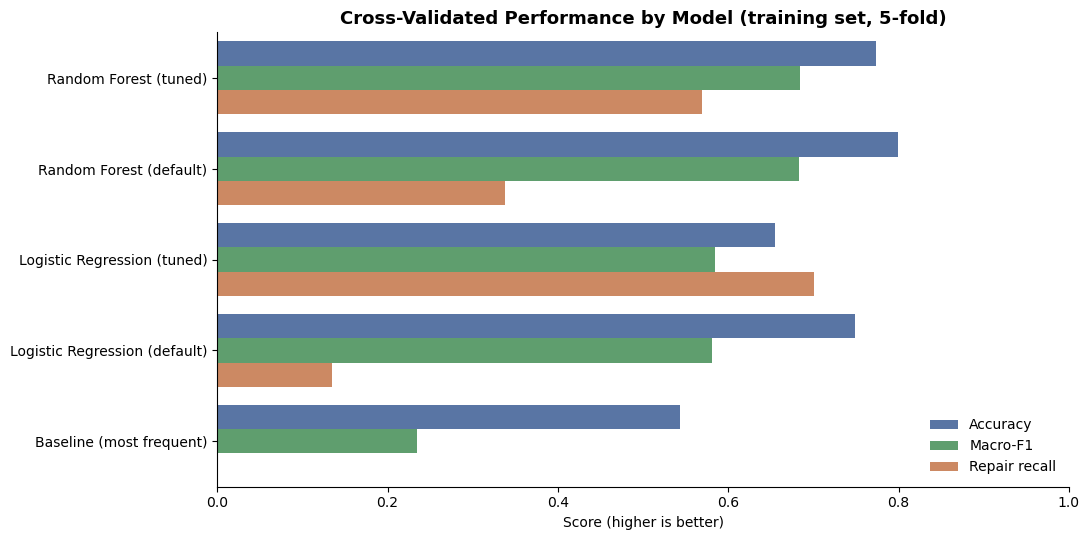

In [46]:
summary = (pd.DataFrame(results).T
           [["accuracy", "macro_f1", "repair_recall", "macro_f1_std", "fit_seconds"]]
           .round(3))
summary.columns = ["Accuracy", "Macro-F1", "Repair recall", "Macro-F1 std (across folds)", "Avg fit time (s)"]
display(summary.sort_values("Macro-F1", ascending=False))

plot_df = summary.reset_index().rename(columns={"index": "Model"}).melt(
    id_vars="Model", value_vars=["Accuracy", "Macro-F1", "Repair recall"], var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=plot_df, y="Model", x="Score", hue="Metric", ax=ax,
            palette=["#4C72B0", "#55A868", "#DD8452"], order=summary.sort_values("Macro-F1").index[::-1])
ax.set_title("Cross-Validated Performance by Model (training set, 5-fold)", fontsize=13, weight="bold")
ax.set_xlabel("Score (higher is better)")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(title="", frameon=False, loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

**Finding.**
- **Both models beat the baseline by a wide margin.** Accuracy rises from 54% to between 66% and 80%, and macro-F1 from 0.24 to between 0.58 and 0.68.
- **Random Forest beats Logistic Regression on macro-F1** (0.68 vs. 0.59 across folds, a gap of about 0.10 that is much larger than the fold-to-fold spread of 0.002 to 0.007). A plausible reason is that failure depends on combinations of features (for example, an old pump of a certain type in a certain region), which a forest can capture and a straight-line model cannot.
- **Tuning did not raise macro-F1 for either model** (0.581 to 0.585 for logistic regression; 0.683 to 0.684 for the forest). What tuning changed is the trade-off: class weighting raised recall on "needs repair" (0.14 to 0.70 for logistic regression; 0.34 to 0.57 for the forest) at the cost of overall accuracy (0.75 to 0.66 and 0.80 to 0.77), because both now flag more points that turn out to be fine.
- **Which version to carry forward is a judgment call**, since macro-F1 is essentially tied within each model. Section 7 compares them on the held-out test set and weighs the trade-off, using the cost of each kind of mistake.

## 7. Model Evaluation and Selection

Up to now the test set has been untouched. This section scores the candidate models on it **once**, and then examines where and how they are wrong.

### 7.1 Metrics used and what they mean

| Metric | What it measures | Why it is used here |
|---|---|---|
| **Accuracy** | Share of all water points classified correctly | Familiar, but misleading when one class is 54% of the data |
| **Precision** (per class) | Of the points the model *labels* as a class, how many truly are | High precision for "needs repair" means few wasted inspection trips |
| **Recall** (per class) | Of the points that *truly are* a class, how many the model finds | High recall for "needs repair" and "non functional" means few failing points are missed |
| **F1** (per class) | A single balance of precision and recall | Summarizes each class in one number |
| **Macro-F1** | Average of the three per-class F1 scores, each class weighted equally | **Primary metric.** It does not let the large "functional" class hide poor performance on the small "needs repair" class |
| **Confusion matrix** | Counts of true class vs. predicted class | Shows *which* mistakes are made, not just how many |

**Why these fit the problem.** The goal is to help a maintenance team find water points that are broken or about to need repair. That makes recall on the two problem classes important, while macro-F1 keeps the overall judgment honest about the rare class.

### 7.2 Test-set performance

The three candidates plus the baseline are scored on the 11,880 held-out water points. The random forest with default settings is refit here so it can be compared on the test set as well. A bootstrap (resampling the test set 500 times) gives a rough 95% interval for each macro-F1, to show how much of a gap could just be luck.

In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

default_rf = make_pipe(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)).fit(X_train, y_train)
baseline = make_pipe(DummyClassifier(strategy="most_frequent")).fit(X_train, y_train)

candidates = {
    "Baseline (most frequent)": baseline,
    "Logistic Regression (tuned)": searches["Logistic Regression (tuned)"].best_estimator_,
    "Random Forest (default)": default_rf,
    "Random Forest (tuned)": searches["Random Forest (tuned)"].best_estimator_,
}
test_pred = {name: est.predict(X_test) for name, est in candidates.items()}

rng = np.random.default_rng(42)
y_test_arr = y_test.to_numpy()
rows = []
for name, pred in test_pred.items():
    boots = []
    for _ in range(500):
        b = rng.integers(0, len(y_test_arr), len(y_test_arr))
        boots.append(f1_score(y_test_arr[b], pred[b], average="macro"))
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro-F1": f1_score(y_test, pred, average="macro"),
        "Macro-F1 95% interval": f"{np.percentile(boots, 2.5):.3f} to {np.percentile(boots, 97.5):.3f}",
        "Repair recall": recall_score(y_test, pred, labels=["functional needs repair"], average="macro"),
        "Non-functional recall": recall_score(y_test, pred, labels=["non functional"], average="macro"),
    })
test_summary = pd.DataFrame(rows).set_index("Model")
display(test_summary.round(3))

,Accuracy,Macro-F1,Macro-F1 95% interval,Repair recall,Non-functional recall
Model,,,,,
Baseline (most frequent),0.543,0.235,0.232 to 0.237,0.000,0.000
Logistic Regression (tuned),0.657,0.588,0.579 to 0.596,0.699,0.662
Random Forest (default),0.805,0.685,0.673 to 0.697,0.330,0.788
Random Forest (tuned),0.774,0.683,0.673 to 0.694,0.576,0.768


**Finding.** On data the models have never seen, the ranking from cross-validation holds, and the scores are close to the cross-validated ones (for example, 0.683 on the test set vs. 0.684 in cross-validation for the tuned forest), which suggests the tuning did not overfit the training data.
- Both models far exceed the baseline (macro-F1 0.235).
- Random Forest beats Logistic Regression: about 0.68 to 0.69 vs. 0.59 macro-F1, and the bootstrap intervals (0.67 to 0.70 vs. 0.58 to 0.60) do not overlap, so this gap is not luck.
- The two forests are statistically indistinguishable on macro-F1 (intervals 0.673 to 0.697 and 0.673 to 0.694 overlap almost completely). They differ in *how* they err: the tuned forest finds 58% of "needs repair" points while the default forest finds 33%.

### 7.3 Per-class precision and recall

In [48]:
for name in ["Logistic Regression (tuned)", "Random Forest (default)", "Random Forest (tuned)"]:
    print(f"\n{name}")
    rep = pd.DataFrame(classification_report(y_test, test_pred[name], output_dict=True)).T
    display(rep.loc[status_order + ["macro avg"], ["precision", "recall", "f1-score", "support"]].round(3))


Logistic Regression (tuned)


,precision,recall,f1-score,support
functional,0.804,0.648,0.718,6452.0
functional needs repair,0.214,0.699,0.327,863.0
non functional,0.784,0.662,0.718,4565.0
macro avg,0.601,0.670,0.588,11880.0



Random Forest (default)


,precision,recall,f1-score,support
functional,0.811,0.881,0.844,6452.0
functional needs repair,0.513,0.330,0.402,863.0
non functional,0.833,0.788,0.810,4565.0
macro avg,0.719,0.666,0.685,11880.0



Random Forest (tuned)


,precision,recall,f1-score,support
functional,0.830,0.805,0.817,6452.0
functional needs repair,0.343,0.576,0.430,863.0
non functional,0.840,0.768,0.802,4565.0
macro avg,0.671,0.716,0.683,11880.0


**Finding.** The "needs repair" class is where models differ most.
- **Logistic Regression** (class-weighted) finds 70% of "needs repair" points, but only 21% of the points it flags really need repair (precision 0.21). It buys recall by flagging a lot of points.
- **The default forest** is the opposite: precision 0.51, recall 0.33. It is right when it speaks up, but it misses two thirds of the points needing repair.
- **The tuned forest** sits in between: it finds 58% of "needs repair" points, and 34% of the points it flags really need repair. Because the rare class is only 7% of the data, a model that catches more of it will inevitably raise more false alarms.
- On "functional" and "non functional", the forests do well (F1 about 0.80 to 0.84) and logistic regression is weaker (F1 about 0.72).

### 7.4 Confusion matrices

Each row is a true class; each cell shows the share of that class sent to each predicted class (with raw counts below). A perfect model would be bright only along the diagonal.

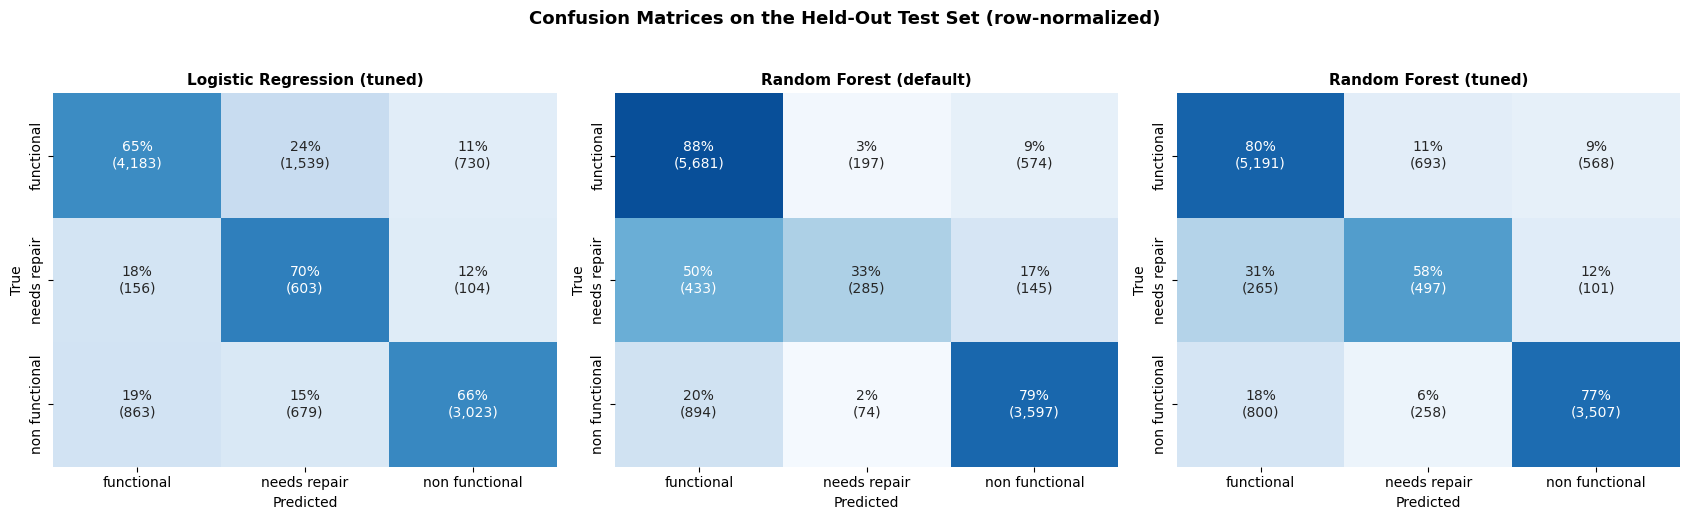

In [49]:
short = {"functional": "functional", "functional needs repair": "needs repair", "non functional": "non functional"}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, name in zip(axes, ["Logistic Regression (tuned)", "Random Forest (default)", "Random Forest (tuned)"]):
    cm = confusion_matrix(y_test, test_pred[name], labels=status_order)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f"{cm_pct[i, j]:.0%}\n({cm[i, j]:,})" for j in range(3)] for i in range(3)])
    sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=ax,
                xticklabels=[short[s] for s in status_order], yticklabels=[short[s] for s in status_order])
    ax.set_title(name, fontsize=11, weight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.suptitle("Confusion Matrices on the Held-Out Test Set (row-normalized)", fontsize=13, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

**Finding.** Reading the tuned forest's matrix (right panel):
- 80% of functional points and 77% of non-functional points are classified correctly.
- Of the points that truly need repair, 58% are caught, but **31% are called "functional"** (the costly miss, since these would be passed over) and 12% are called "non functional".
- In the other direction, 11% of functional points are flagged as "needs repair", which is where the false alarms come from.
- The middle panel (default forest) misses half of the "needs repair" points, calling them functional. The left panel (logistic regression) catches most of them, but wrongly sends 24% of functional points to "needs repair".
- The pattern makes sense: "functional needs repair" sits between the other two classes and looks similar to both.

### 7.5 Does a random split flatter the model? A location-grouped check

Section 4.6 showed that neighboring water points tend to share a condition, so a random split may leave near-neighbors on both sides of the train/test line. To measure this, the training set is re-split so that **all water points from the same local government area (`lga`) fall in the same fold**. Each model is then tested on areas it never saw during training. If scores drop a lot, the random-split results are over-optimistic for new areas.

In [50]:
from sklearn.model_selection import GroupKFold

group_cv = GroupKFold(n_splits=5)
groups = X_train["lga"].fillna("unknown")

grouped = {}
for name in ["Logistic Regression (tuned)", "Random Forest (tuned)"]:
    sc = cross_validate(candidates[name], X_train, y_train, cv=group_cv, groups=groups,
                        scoring={"macro_f1": "f1_macro", "accuracy": "accuracy"}, n_jobs=-1)
    grouped[name] = {"Random-split macro-F1": results[name]["macro_f1"],
                     "Location-grouped macro-F1": sc["test_macro_f1"].mean(),
                     "Random-split accuracy": results[name]["accuracy"],
                     "Location-grouped accuracy": sc["test_accuracy"].mean()}
grouped_df = pd.DataFrame(grouped).T
grouped_df["Macro-F1 drop"] = grouped_df["Random-split macro-F1"] - grouped_df["Location-grouped macro-F1"]
display(grouped_df.round(3))

,Random-split macro-F1,Location-grouped macro-F1,Random-split accuracy,Location-grouped accuracy,Macro-F1 drop
Logistic Regression (tuned),0.585,0.545,0.655,0.651,0.041
Random Forest (tuned),0.684,0.533,0.774,0.706,0.151


**Finding.** The random split is optimistic, and much more so for the forest. When the models are tested on districts they never saw during training, macro-F1 falls from 0.684 to 0.533 for the forest (a drop of 0.15) but only from 0.585 to 0.545 for logistic regression (a drop of 0.04). On new districts the simpler linear model is as good as the forest, and slightly better (0.545 vs. 0.533, a small difference that comes from only five folds). A plausible explanation, which I did not test, is that the forest learns local patterns (specific districts, coordinates, and who manages points there) that help for nearby points but do not carry over to a new district.

What this means in practice: the headline test numbers describe the situation "predict the status of *other* water points in districts where many points have already been surveyed", which is a realistic use for an agency that already has survey data. They should **not** be read as how well the model would work in a district with no data. For that case, expect macro-F1 around 0.53 to 0.55, and the extra complexity of the forest buys nothing.

### 7.6 Final model selection

**Selected model: the tuned Random Forest** (class-balanced, `max_depth = 30`, `min_samples_leaf = 2`, 150 trees), for use where nearby water points have already been surveyed.

**Evidence.**
1. **It clearly beats Logistic Regression on the held-out test set.** Macro-F1 of 0.683 vs. 0.588 with non-overlapping bootstrap intervals, and higher F1 on every class.
2. **It ties the default forest on macro-F1** (0.683 vs. 0.685, well within noise), so the choice between the two forests is made on the cost of mistakes, not on the score. For a maintenance program, a missed "needs repair" point stays broken and gets worse, while a false alarm costs an inspection visit. The class-balanced forest catches 58% of the points needing repair instead of 33%, at the price of lower accuracy (0.77 vs. 0.81) and more false alarms.
3. **Logistic Regression is a weaker choice for this use.** Its class weighting finds 70% of "needs repair" points, but only 21% of its flags are right and overall accuracy is just 0.66.

**Trade-offs.**

| | Logistic Regression | Random Forest (default) | **Random Forest (tuned)** |
|---|---|---|---|
| Macro-F1 (test) | 0.588 | 0.685 | **0.683** |
| Accuracy (test) | 0.657 | 0.805 | **0.774** |
| Finds "needs repair" | 70% | 33% | **58%** |
| Precision on "needs repair" | 0.21 | 0.51 | **0.34** |
| Macro-F1 on unseen districts (CV) | 0.545 | not tested | **0.533** |
| Easy to explain | Yes | No | No |

**An important caveat.** On unseen districts the forest's advantage disappears (Section 7.5). If the model were to be used in an area with no survey data, the simpler logistic regression would be the better choice: it is as accurate there and far easier to explain. If the team's inspection budget were very small, the default forest's higher precision would be the better pick, since fewer visits would be wasted. If missing a failing pump is the bigger worry, the tuned forest is better.

## 8. Model Interpretation and Insights

The final model is examined with several tools: permutation importance (which features the model relies on), a test of how much the `quantity` feature is doing, partial dependence (how predictions change with a feature), Logistic Regression coefficients (direction of effects), and error analysis (where the model fails).

### 8.1 Which features matter most? (permutation importance)

Permutation importance shuffles one original column at a time on the test set and measures how much macro-F1 falls. A big drop means the model relied on that feature. It works on the original 20 columns, so one-hot columns are not split into dozens of tiny pieces.

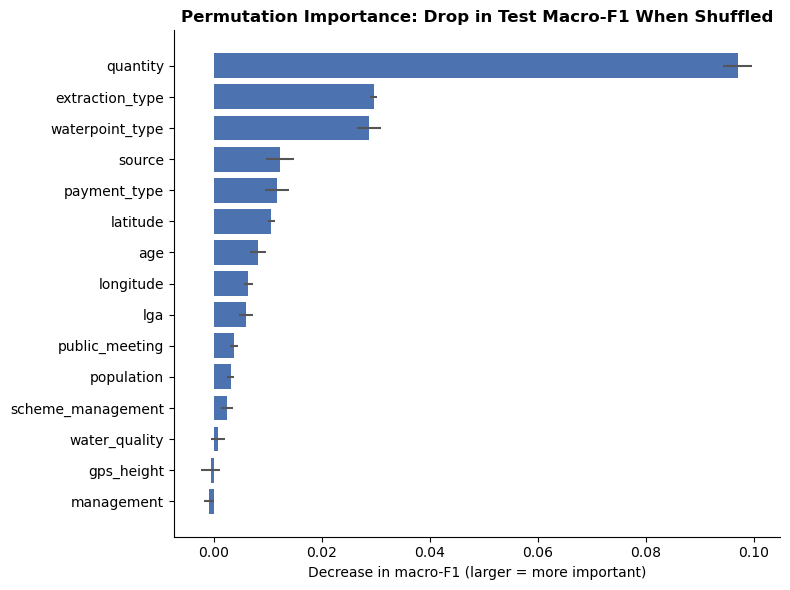

,feature,drop,std
0,quantity,0.0970,0.0027
1,extraction_type,0.0296,0.0007
2,waterpoint_type,0.0287,0.0022
3,source,0.0123,0.0026
4,payment_type,0.0117,0.0022
5,latitude,0.0106,0.0007
6,age,0.0082,0.0015
7,longitude,0.0064,0.0009
8,lga,0.0059,0.0013
9,public_meeting,0.0037,0.0008


In [51]:
from sklearn.inspection import permutation_importance

final_model = candidates["Random Forest (tuned)"]
perm = permutation_importance(final_model, X_test, y_test, scoring="f1_macro",
                              n_repeats=5, random_state=42, n_jobs=-1)
perm_df = (pd.DataFrame({"feature": X_test.columns, "drop": perm.importances_mean, "std": perm.importances_std})
           .sort_values("drop", ascending=False))

top = perm_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["drop"], xerr=top["std"], color="#4C72B0", ecolor="#555555")
ax.set_title("Permutation Importance: Drop in Test Macro-F1 When Shuffled", fontsize=12, weight="bold")
ax.set_xlabel("Decrease in macro-F1 (larger = more important)")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()
display(perm_df.head(10).round(4).reset_index(drop=True))

**Finding.** `quantity` is by far the most relied-on feature: shuffling it alone lowers macro-F1 by about 0.10, over three times more than any other feature. After it come the technology of the water point (`extraction_type`, `waterpoint_type`), then `source`, `payment_type`, location (`latitude`, `longitude`), and `age`. The remaining features contribute little once the others are known.

This lines up with the research in Section 2: technology type and payment/management arrangements (Foster, 2013; Jiménez & Pérez-Foguet, 2011) and age (Foster, 2013) all show up among the influential features. Permutation importance shows what the model *uses*, not what *causes* failure.

### 8.2 How much is `quantity` doing? (leakage test)

Section 4.5 flagged `quantity` as partly a consequence of a point being broken. To see how much the model depends on it, the same tuned random forest is retrained **without** `quantity` and scored on the same test set.

In [52]:
rf_params = {k.replace("model__", ""): v for k, v in searches["Random Forest (tuned)"].best_params_.items()}

cat_no_q = [c for c in cat_cols if c != "quantity"]
prep_no_q = ColumnTransformer([
    ("num", clone(num_pipe), num_cols),
    ("flag", "passthrough", flag_cols),
    ("cat", clone(cat_pipe), cat_no_q),
])
no_q = Pipeline([("prep", prep_no_q),
                 ("model", RandomForestClassifier(random_state=42, n_jobs=-1, **rf_params))]).fit(X_train, y_train)
pred_no_q = no_q.predict(X_test)

compare_q = pd.DataFrame({
    "With quantity": [accuracy_score(y_test, test_pred["Random Forest (tuned)"]),
                      f1_score(y_test, test_pred["Random Forest (tuned)"], average="macro"),
                      recall_score(y_test, test_pred["Random Forest (tuned)"], labels=["functional needs repair"], average="macro")],
    "Without quantity": [accuracy_score(y_test, pred_no_q),
                         f1_score(y_test, pred_no_q, average="macro"),
                         recall_score(y_test, pred_no_q, labels=["functional needs repair"], average="macro")],
}, index=["Accuracy", "Macro-F1", "Repair recall"])
display(compare_q.round(3))

,With quantity,Without quantity
Accuracy,0.774,0.740
Macro-F1,0.683,0.658
Repair recall,0.576,0.590


**Finding.** Without `quantity`, the model still works, but worse: macro-F1 falls from 0.683 to 0.658 and accuracy from 0.774 to 0.740. Recall on "needs repair" does not fall (0.576 to 0.590), so the lost performance is on the other two classes.

The fall is much smaller than the permutation importance (0.10) suggested, because when `quantity` is removed the model can partly rebuild the same signal from `extraction_type`, `waterpoint_type`, `payment_type`, and location. Two conclusions: the model does not rest entirely on `quantity`, and it is not a pure artifact of it either. But the 0.025 gap is the part that comes from knowing how much water the point yields, and a dry point is, to a large extent, a broken one. This is also why real-world forecasting of *future* failure would be harder than these numbers suggest.

### 8.3 Direction of effects: Logistic Regression coefficients

The linear model is easier to read than the forest. In this three-class model each class has its own coefficients. A positive coefficient pushes the model's score for "non functional" up and a negative one pushes it down. Numeric features are standardized, so a coefficient is the effect of a one-standard-deviation change; a category's coefficient compares that level with the average level. Individual districts, regions and basins are left out of the chart because there are hundreds of them and each is a small, place-specific effect.

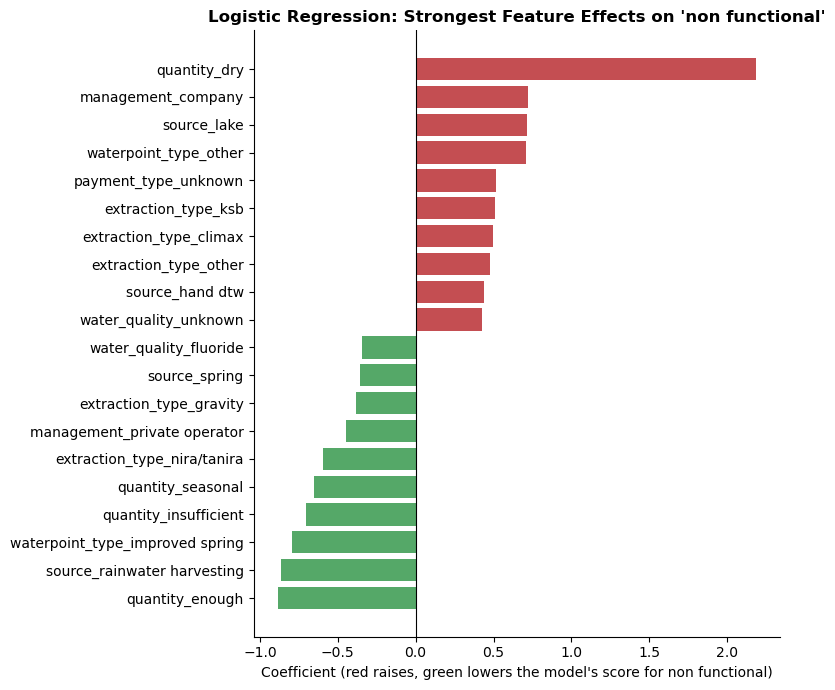

In [53]:
lr_pipe = candidates["Logistic Regression (tuned)"]
prep = lr_pipe.named_steps["prep"]

# Rebuild readable column names in the same order the ColumnTransformer outputs them
names = (num_cols + flag_cols
         + list(prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)))
lr = lr_pipe.named_steps["model"]
assert len(names) == lr.coef_.shape[1]

k = list(lr.classes_).index("non functional")
coef = pd.Series(lr.coef_[k], index=names)
# Leave out place-specific levels (individual districts, regions, basins):
# they are numerous and hard to generalize from, and are covered by the permutation analysis above
place_prefixes = ("lga_", "region_", "basin_")
coef = coef[~coef.index.str.startswith(place_prefixes)].sort_values()
plot_c = pd.concat([coef.head(10), coef.tail(10)])

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_c.index, plot_c.values, color=["#55A868" if v < 0 else "#C44E52" for v in plot_c.values])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression: Strongest Feature Effects on 'non functional'", fontsize=12, weight="bold")
ax.set_xlabel("Coefficient (red raises, green lowers the model's score for non functional)")
sns.despine()
plt.tight_layout()
plt.show()

**Finding.** The linear model agrees with the forest on direction.
- **Raising the score for non functional:** a `dry` water point (by far the strongest), company-managed points, lake sources, the "other" water-point and extraction types (the catch-all categories seen in Section 4.5), and unknown payment type or water quality.
- **Lowering it:** `enough` water, rainwater harvesting, improved springs, spring sources, gravity-fed systems, and points run by private operators. The private-operator result is consistent with Jiménez and Pérez-Foguet (2011), who found that privately operated water points had lower failure rates than village-committee ones.
- The vague "other" and "unknown" categories carrying risk is a useful result in itself: it means incomplete records are a warning sign.

### 8.4 Where does the model go wrong? (error analysis)

First, the error rate of the final model for different kinds of water points, using only groups with at least 150 test points so tiny groups are not over-read. Then, the most confident mistakes.

In [54]:
err_df = X_test.copy()
err_df["true"] = y_test.values
err_df["pred"] = test_pred["Random Forest (tuned)"]
err_df["wrong"] = err_df["true"] != err_df["pred"]

proba = final_model.predict_proba(X_test)
classes = list(final_model.classes_)
err_df["confidence"] = proba.max(axis=1)
worst = (err_df[err_df["wrong"]]
         .sort_values("confidence", ascending=False)
         .head(8)[["true", "pred", "confidence", "waterpoint_type", "quantity", "age", "payment_type", "region"]])
print("Most confident wrong predictions:")
display(worst.round(2))

print("\nWhat happens to each true class (share of that class sent to each prediction):")
display(pd.crosstab(err_df["true"], err_df["pred"], normalize="index").round(2))

Most confident wrong predictions:


,true,pred,confidence,waterpoint_type,quantity,age,payment_type,region
48613,non functional,functional,0.97,communal standpipe,seasonal,19.0,per bucket,Arusha
29999,functional,non functional,0.97,other,enough,14.0,unknown,Lindi
3636,non functional,functional,0.97,communal standpipe,enough,21.0,monthly,Iringa
2459,non functional,functional,0.97,communal standpipe,seasonal,19.0,per bucket,Arusha
37238,functional,non functional,0.96,other,enough,29.0,never pay,Morogoro
56876,functional,non functional,0.96,other,enough,NaN,never pay,Tabora
9273,functional needs repair,non functional,0.96,other,enough,NaN,never pay,Mwanza
53160,non functional,functional,0.96,communal standpipe,enough,11.0,never pay,Iringa



What happens to each true class (share of that class sent to each prediction):


pred,functional,functional needs repair,non functional
true,,,
functional,0.80,0.11,0.09
functional needs repair,0.31,0.58,0.12
non functional,0.18,0.06,0.77


**Finding.**
- **By water-point type:** the model is *worse* on hand pumps (26% wrong) and improved springs (30%) than on communal standpipes (23%), and much better on the catch-all "other" type (14%), where most points are non-functional anyway.
- **By `quantity`:** the model almost never errs on dry points (2% wrong), because a dry point is nearly always non-functional. It struggles most with `seasonal` (35% wrong) and `insufficient` (29%) water points, which is where the future status is genuinely uncertain.


### 8.6 What the model tells us, and what it cannot

**What the model learned.** A water point is more likely to be broken if it is dry or short on water, is of an unusual or poorly recorded type, is old, has no payment system, or is managed by a company rather than a community-based or public operator. Where it sits matters too. These patterns agree with the earlier research reviewed in Section 2.

**Where it works and where it does not.** It is strong at separating "functional" from "non functional" (77% and 80% recall), moderate at the rare "needs repair" class (58% recall, 34% precision), and weaker in seasonal-water points, hand pumps, and certain regions such as Kigoma.

**What can be concluded.**
- Condition can be predicted well above chance from information a survey team can record once.
- The strongest predictors are the amount of water, the technology, the payment/management setup, the age, and the location.

**What cannot be concluded.**
- Payment type, management, and age are associated with failure. The data cannot show that changing any of them would fix it.
- The labels are a snapshot, and features like `quantity` partly reflect the failure itself.
- Performance drops sharply (macro-F1 about 0.53 to 0.55) in districts with no prior data, and there the simple logistic regression does as well as the forest. So the model would not perform well in new districts.

## 9. Limitations, Ethics, and Reflection

### 9.1 Biases and gaps in the data
- **Old data.** Records date from 2002 to 2013 (almost all 2011 to 2013). Water points, technologies, and maintenance practices in Tanzania have changed since, so the patterns may not hold today.
- **A snapshot, not a history.** Each label is the condition at the time of one survey. A point labelled functional may have failed a month later, and a "needs repair" point may have been fixed. The model learns from one moment, so it cannot predict *when* a point will fail.
- **Uneven coverage and uneven quality.** The data was gathered by surveyors and crowdsourced reports, so some regions are covered far more thoroughly than others (for example, the test set has about 1,000 points from Iringa and Shinyanga but only about 170 from Dar es Salaam). Fields were also filled in inconsistently.
- **Hidden missing values.** About a third of `gps_height`, `population`, and `construction_year` were recorded as 0, and about 48% of `scheme_name` is blank. I treated the zeros as missing and filled them with the median, which assumes those points look like typical ones. That may not be true: points that are poorly documented may be the ones that are neglected.
- **Features that partly describe the outcome.** `quantity` (how much water a point yields) is partly a result of a point being broken, so it makes the task look easier than forecasting future failure (Section 8.2).
- **Only Tanzania.** Nothing here shows the model would transfer to another country.

### 9.2 Who is affected by incorrect predictions
The people most affected are the **communities that depend on a water point**, often in rural areas with few alternatives, and not the agency that uses the model. Mistakes are also not spread evenly: the tuned forest is wrong for about 9% of points in Dar es Salaam but about 40% in Kigoma (Section 8.5), so the burden of errors would fall unevenly on some regions. Agency staff are affected too, since they spend limited time and money on the model's recommendations.

### 9.3 Consequences of different errors
| Error | What happens | How often (tuned forest, test set) |
|---|---|---|
| **"Needs repair" called "functional"** (false negative) | The point is skipped, deteriorates, and eventually fails. People lose water that a cheap repair could have saved | 31% of points that truly need repair |
| **"Non functional" called "functional"** (false negative) | A broken point stays on the "working" list. People walk to a dry pump, or use unsafe sources | 18% of non-functional points |
| **"Functional" called "needs repair"** (false positive) | A crew is sent to a point that does not need work, wasting scarce time and money | 11% of functional points; overall only 34% of "needs repair" flags are correct |

The models were tuned toward catching more "needs repair" points (recall 58% instead of 33%), which means accepting more wasted visits. That is a value judgment about which error is worse, and the people who run the program, not the modeler, should make it, ideally with input from the affected communities.

### 9.4 Is the model appropriate for real-world decisions?
**As a screening aid, with limits: yes. As the decision-maker: no.**
- It is reasonable for **ranking** water points in districts that already have survey data, to help decide which to inspect first. It beats guessing by a wide margin (macro-F1 0.68 vs. 0.24).
- It is **not** reliable enough to decide on its own which points to repair or abandon, or to allocate funds between regions: it misses about 3 in 10 points needing repair, its errors vary by region, and it can be very confident and wrong (Section 8.5).
- In **districts with no survey data** it performs much worse (macro-F1 about 0.53 to 0.55), and a simpler logistic regression does just as well.
- The data is more than a decade old, so any real use would need fresh data, and every flagged point should be verified in the field.

### 9.5 What I would explore next
- **More recent data**, and repeat surveys of the same points, so the model could predict failure *within* a time window rather than describe a snapshot.
- **New features** that earlier research suggests matter, such as distance to the district capital or a repair center (Foster, 2013), rainfall, and whether a maintenance contract exists.

### 9.6 What users should understand before relying on the model
1. The model shows **association, not cause**. Payment type, management, and age predict failure, but the data cannot show that changing them would prevent it.
2. It describes a **past snapshot**, not the future.
3. Its **headline accuracy is for places it has already seen**. For new districts, expect much weaker results.
4. It is **weakest on the class that matters most**: it finds about 58% of points needing repair, and most of its repair flags are wrong.
5. **Confidence is not correctness.** A 97% prediction can still be wrong, and it should be treated as a prompt to check, not a verdict.

## 10. Code and Transparency

### 10.1 Code
- **Code repository:** *(https://lbouromm-sketch.github.io/Data-Science-Portfolio/)*
- **This notebook:** `Project2_LuxorB.ipynb`. Running it from top to bottom reproduces every number and figure. Random seeds are fixed (`random_state = 42`), so results should repeat.


### 10.2 Data and references
- **Data:** DrivenData (n.d.), *Pump it up: Data mining the water table*, collected by Taarifa and the Tanzanian Ministry of Water. Full link and citation are in the References below. Check the competition's terms before re-sharing the data files.
- **Documentation and tools:** scikit-learn documentation (for the pipeline, cross-validation, and permutation importance tools), and the sources cited in Section 2.

### 10.3 AI usage disclosure
- **Tool and version:** Claude Sonnet 5.5 (`claude-sonnet-5-5`), by Anthropic.
- **What it was used for:**
  - Drafting and editing the Python code in this notebook (data cleaning, the preprocessing pipeline, model training and tuning, evaluation, and plots), and debugging it.
  - Reorganizing the notebook to follow the assignment outline, and explaining concepts such as the preprocessing pipeline and hyperparameter tuning.

## References

Chellaraj, G., Joseph, G., Grabinsky Zabludovsky, J., Andres, L. A., Ayling, S. C. E., & Hoo, Y. R. (2019). *Why do so many water points fail in Tanzania? An empirical analysis of contributing factors* (Policy Research Working Paper No. 8729). World Bank. https://doi.org/10.1596/1813-9450-8729

DrivenData. (n.d.). *Pump it up: Data mining the water table* [Data set]. https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/

Foster, T. (2013). Predictors of sustainability for community-managed handpumps in sub-Saharan Africa: Evidence from Liberia, Sierra Leone, and Uganda. *Environmental Science & Technology, 47*(21), 12037–12046. https://doi.org/10.1021/es402086n

Foster, T., Furey, S., Banks, B., & Willetts, J. (2020). Functionality of handpump water supplies: A review of data from sub-Saharan Africa and the Asia-Pacific region. *International Journal of Water Resources Development, 36*(5), 855–869. https://doi.org/10.1080/07900627.2018.1543117

Jiménez, A., & Pérez-Foguet, A. (2011). The relationship between technology and functionality of rural water points: Evidence from Tanzania. *Water Science and Technology, 63*(5), 948–955. https://doi.org/10.2166/wst.2011.274